<a href="https://colab.research.google.com/github/ishika240047/CS.23.204/blob/main/Raksha22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving raksha2.xlsx to raksha2.xlsx


In [4]:
import pandas as pd

# Read the uploaded Excel file into a DataFrame
try:
    df = pd.read_excel('raksha2.xlsx')
    print("Data loaded successfully from raksha2.xlsx")
    display(df.head())
except FileNotFoundError:
    print("Error: 'raksha2.xlsx' not found. Please ensure the file is uploaded to your Colab environment or specify the correct path.")
except Exception as e:
    print(f"An error occurred while reading the Excel file: {e}")

Data loaded successfully from raksha2.xlsx


,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,CreatedOn,year,month
0,KARNATAKA,HUBBALLI,PUSAD,NaN,HORTICULTURE,Others,Others,Market,Farmer asked about sowing time of Onion?,2025-03-20T06:45:00,2025,3
1,MAHARASHTRA,AKOLA,SAKOLI,NaN,HORTICULTURE,Others,Others,Market,FARMER ASKED ABOUT FERTILIZER DOSES FOR CITRUS...,2025-03-08T02:35:00,2025,3
2,MAHARASHTRA,LATUR,PUSAD,NaN,AGRICULTURE,Others,Others,Market,FARMER ASKED ABOUT CONTROL OF BLIGHT ATTACK ON...,2025-02-03T08:13:00,2025,2
3,UTTAR PRADESH,LUCKNOW,SAKOLI,NaN,HORTICULTURE,Others,Others,Market,FARMER ASKED ABOUT FARMER ID CARD PROBLEM?,2025-03-10T02:44:00,2025,3
4,MAHARASHTRA,LATUR,PAUNI,NaN,AGRICULTURE,Others,Others,Market,Farmer asked about irrigation schedule for Onion?,2025-02-02T11:51:00,2025,2


In [5]:
df.columns

Index(['StateName', 'DistrictName', 'BlockName', 'Season', 'Sector',
       'Category', 'Crop', 'QueryType', 'QueryText', 'CreatedOn', 'year',
       'month'],
      dtype='object')

In [6]:
# Count the occurrences of each unique value in the 'QueryType' column
query_category_counts = df['QueryType'].value_counts()

# Display the counts
display(query_category_counts)

,count
QueryType,
Market,357
Plant Protection,348
Weather,334
Government Schemes,334
Nutrient Management,323
Seeds,304


/tmp/ipykernel_4726/1704545895.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=query_category_counts.index, y=query_category_counts.values, palette='viridis')


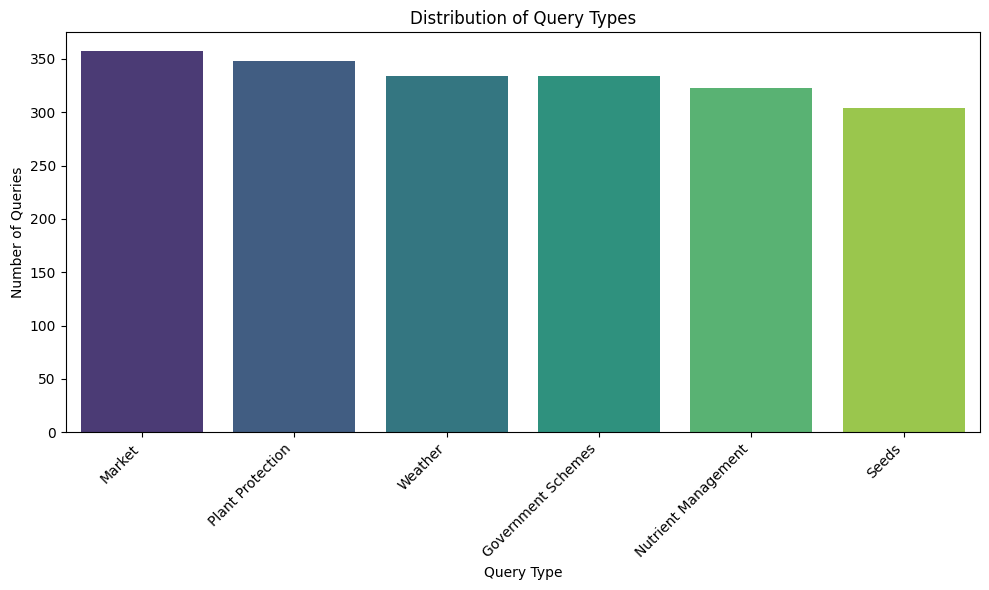

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot of the query category counts
plt.figure(figsize=(10, 6))
sns.barplot(x=query_category_counts.index, y=query_category_counts.values, palette='viridis')
plt.title('Distribution of Query Types')
plt.xlabel('Query Type')
plt.ylabel('Number of Queries')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

In [8]:
# Calculate the frequency of queries by month
monthly_query_counts = df['month'].value_counts().sort_index()

# Display the counts
display(monthly_query_counts)

,count
month,
1,730
2,667
3,603


The above output shows the number of queries for each month present in the dataset, sorted by month number.

### Define New Query Categories based on Keywords

To re-categorize the `QueryType` column, please define a dictionary where keys are the new `QueryType` names, and values are lists of keywords associated with that category. I will then use these keywords to assign a new `QueryType` to each query based on the presence of these keywords in the `QueryText`.

**Instructions:**
1.  **Add/Modify Categories:** Change the category names (keys) in the `category_keywords` dictionary to your desired `QueryType`s.
2.  **Add Keywords:** For each category, list relevant keywords that should identify a query as belonging to that category. Keywords are case-insensitive.
3.  **Review existing categories:** You can use the previous unique categories as a starting point: `Market`, `Plant Protection`, `Nutrient Management`, `Seeds`, `Government Schemes`, `Weather`.

In [11]:
# Define your new category mappings here.
# Each key is a new category name, and its value is a list of keywords.
# Keywords will be searched for (case-insensitively) in the 'QueryText'.
category_keywords = {
    'Market Information': ['market rate', 'price', 'sale', 'buy', 'sell'],
    'Plant Disease & Pest Control': ['blight', 'pest', 'disease', 'control', 'fungicide', 'insecticide'],
    'Crop & Nutrient Management': ['fertilizer', 'nutrient', 'sowing', 'weed', 'irrigation', 'management', 'crop', 'soil'],
    'Seeds & Varieties': ['seed', 'variety', 'hybrid'],
    'Government Schemes & Subsidies': ['scheme', 'yojana', 'subsidy', 'government', 'status', 'PM Kisan'],
    'Weather & Climate': ['weather', 'rain', 'temperature', 'climate', 'forecast'],
    'Other': [] # A catch-all for queries that don't match any specific keywords
}

### Query Classification Function

Below is the Python function `assign_new_query_type` that encapsulates the logic for categorizing queries based on the `category_keywords` dictionary. This function iterates through the defined categories and their associated keywords, assigning a query to the first category where a matching keyword is found in the `QueryText`. If no keywords match, it defaults to the 'Other' category.

In [14]:
def assign_new_query_type(query_text):
    """Assigns a new query type based on keywords present in the query text."""
    query_text_lower = str(query_text).lower()
    for category, keywords in category_keywords.items():
        for keyword in keywords:
            if keyword in query_text_lower:
                return category
    return 'Other' # Default category if no keywords match

This `assign_new_query_type` function was used previously to create the `New_QueryType` column and subsequently replace the original `QueryType` column in your DataFrame with the re-categorized values. You can now call this function on any new `QueryText` to classify it according to your defined rules.

### Demonstrating the `assign_new_query_type` function

Here are some examples of how the `assign_new_query_type` function classifies `QueryText` entries based on the `category_keywords` you defined.

In [15]:
for query_text in sample_queries:
    classified_type = assign_new_query_type(query_text)
    print(f"Query: '{query_text}' -> Classified as: '{classified_type}'")

Query: 'Farmer asked about fertilizer dose for Soybean?' -> Classified as: 'Crop & Nutrient Management'
Query: 'FARMER ASKED ABOUT MARKET RATE OF TUR IN LATUR MARKET?' -> Classified as: 'Market Information'
Query: 'FARMER ASKED ABOUT STATUS OF PRADHANMANTRI KISAN SANMAN NIDHI YOJANA ?' -> Classified as: 'Government Schemes & Subsidies'


Once you have defined the `category_keywords` dictionary, run the next cell to apply the re-categorization. Queries will be assigned to the **first category** whose keywords are found in the `QueryText` (so order matters if keywords overlap).

In [13]:
def assign_new_query_type(query_text):
    query_text_lower = str(query_text).lower()
    for category, keywords in category_keywords.items():
        for keyword in keywords:
            if keyword in query_text_lower:
                return category
    return 'Other' # Default category if no keywords match

# Apply the new categorization
df['New_QueryType'] = df['QueryText'].apply(assign_new_query_type)

# Display the new distribution of query types
print("New distribution of query types:")
display(df['New_QueryType'].value_counts())

# Replace the old 'QueryType' column with the new one
df['QueryType'] = df['New_QueryType']
df = df.drop(columns=['New_QueryType']) # Drop the temporary column if you replaced it


New distribution of query types:


,count
New_QueryType,
Crop & Nutrient Management,828
Other,290
Plant Disease & Pest Control,283
Market Information,235
Government Schemes & Subsidies,174
Weather & Climate,125
Seeds & Varieties,65


/tmp/ipykernel_4726/2288966479.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=new_query_category_counts.index, y=new_query_category_counts.values, palette='viridis')


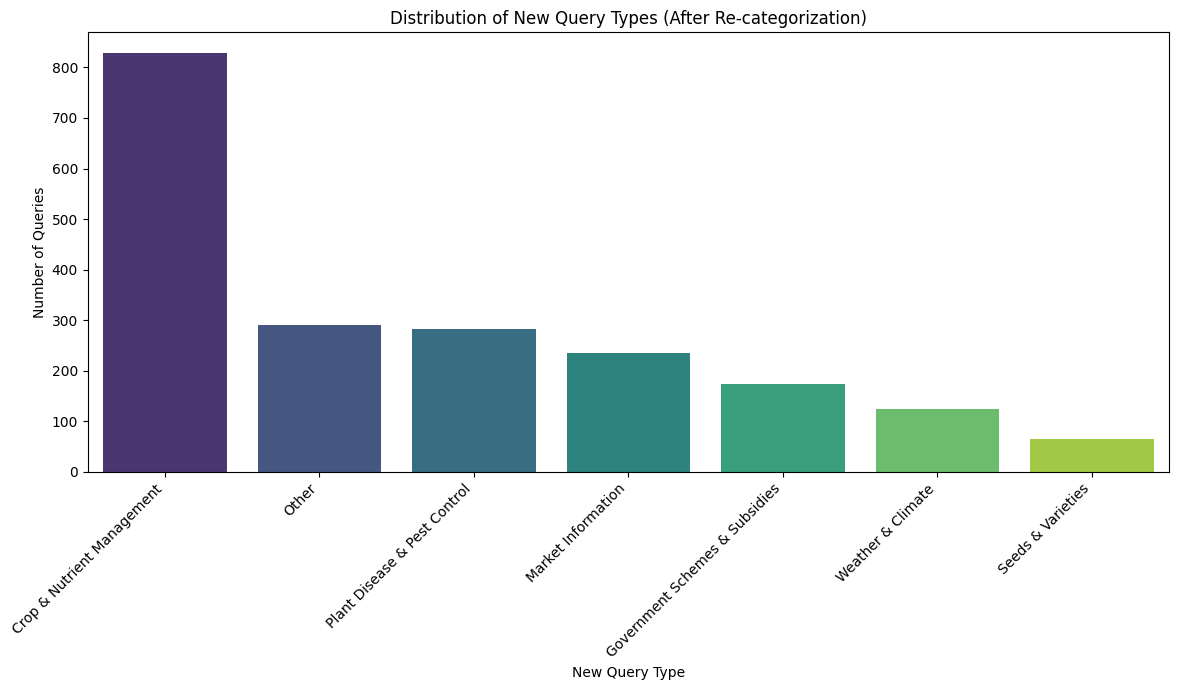

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each unique value in the updated 'QueryType' column
new_query_category_counts = df['QueryType'].value_counts()

# Create a bar plot of the new query category counts
plt.figure(figsize=(12, 7))
sns.barplot(x=new_query_category_counts.index, y=new_query_category_counts.values, palette='viridis')
plt.title('Distribution of New Query Types (After Re-categorization)')
plt.xlabel('New Query Type')
plt.ylabel('Number of Queries')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

### Generating Query Embeddings for Similarity Search

To facilitate finding similar questions, we will convert each `QueryText` into a high-dimensional vector, or 'embedding'. These embeddings capture the semantic meaning of the text, allowing us to find queries that are semantically similar even if they don't share the exact same keywords. We'll use the `sentence-transformers` library for this purpose, which provides access to many pre-trained models.

In [17]:
# Install the sentence-transformers library
!pip install -U sentence-transformers

In [18]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence embedding model
# 'all-MiniLM-L6-v2' is a good balance of speed and performance
model = SentenceTransformer('all-MiniLM-L6-v2')

print("Sentence embedding model loaded successfully.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Sentence embedding model loaded successfully.


In [19]:
# Generate embeddings for each QueryText
# Ensure 'QueryText' column is of string type to avoid errors
df['QueryText_Embedding'] = df['QueryText'].astype(str).apply(lambda x: model.encode(x))

print("Embeddings generated for all queries.")
print(f"Shape of the first embedding: {df['QueryText_Embedding'].iloc[0].shape}")

# Display the DataFrame with the new embedding column (showing only a snippet)
display(df[['QueryText', 'QueryText_Embedding']].head())

Embeddings generated for all queries.
Shape of the first embedding: (384,)


,QueryText,QueryText_Embedding
0,Farmer asked about sowing time of Onion?,"[-0.056796785, 0.092238344, -0.028197434, 0.05..."
1,FARMER ASKED ABOUT FERTILIZER DOSES FOR CITRUS...,"[0.013796639, 0.057277504, -0.052635986, 0.063..."
2,FARMER ASKED ABOUT CONTROL OF BLIGHT ATTACK ON...,"[-0.00933589, 0.05537257, -0.0013083844, 0.068..."
3,FARMER ASKED ABOUT FARMER ID CARD PROBLEM?,"[-0.016197272, 0.09696532, -0.02940295, -0.023..."
4,Farmer asked about irrigation schedule for Onion?,"[-0.05657022, 0.039421733, -0.022073343, 0.030..."


### Similar Question Retrieval Function

Now, let's create a function that will take a new query text, convert it into an embedding using our loaded model, and then find the top N most similar queries from your `df` DataFrame based on cosine similarity.

In [20]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def find_similar_queries(new_query_text, df, model, top_n=5):
    """Finds the top N most similar queries in the DataFrame.

    Args:
        new_query_text (str): The text of the new query to compare.
        df (pd.DataFrame): The DataFrame containing 'QueryText' and 'QueryText_Embedding'.
        model (SentenceTransformer): The loaded sentence embedding model.
        top_n (int): The number of most similar queries to retrieve.

    Returns:
        pd.DataFrame: A DataFrame with the top N similar queries and their similarity scores.
    """
    # 1. Encode the new query
    new_query_embedding = model.encode(new_query_text)

    # 2. Calculate cosine similarity with all existing queries
    # Convert the list of embeddings to a 2D numpy array for efficient calculation
    corpus_embeddings = np.array(df['QueryText_Embedding'].tolist())
    similarities = cosine_similarity([new_query_embedding], corpus_embeddings)[0]

    # 3. Get the indices of the top N most similar queries
    top_n_indices = similarities.argsort()[-top_n:][::-1]

    # 4. Retrieve and display the similar queries
    similar_queries_df = df.iloc[top_n_indices].copy()
    similar_queries_df['Similarity_Score'] = similarities[top_n_indices]

    return similar_queries_df[['QueryText', 'QueryType', 'Similarity_Score']]

print("Similar query retrieval function defined.")

Similar query retrieval function defined.


### Example: Using the Similar Question Retrieval Function

Let's test our `find_similar_queries` function with an example. We will use a new query and see which existing queries from your dataset are most similar.

In [21]:
example_query = "What is the best fertilizer for my wheat crop?"

print(f"Searching for queries similar to: '{example_query}'\n")

similar_results = find_similar_queries(example_query, df, model, top_n=3)
display(similar_results)

Searching for queries similar to: 'What is the best fertilizer for my wheat crop?'



,QueryText,QueryType,Similarity_Score
1373,Farmer asked about fertilizer dose for Wheat?,Crop & Nutrient Management,0.731118
1188,Farmer asked about fertilizer dose for Wheat?,Crop & Nutrient Management,0.731118
1009,Farmer asked about fertilizer dose for Wheat?,Crop & Nutrient Management,0.731118


In [23]:
my_new_query = input("Enter your query to find similar questions: ")

if my_new_query:
    print(f"\nSearching for queries similar to: '{my_new_query}'\n")
    user_similar_results = find_similar_queries(my_new_query, df, model, top_n=5)
    display(user_similar_results)
else:
    print("Please enter a query to search for similar questions.")

Enter your query to find similar questions: government schemes for farmers

Searching for queries similar to: 'government schemes for farmers'



,QueryText,QueryType,Similarity_Score
245,Farmer asked about government subsidy for Wheat?,Government Schemes & Subsidies,0.649241
429,Farmer asked about government subsidy for Wheat?,Government Schemes & Subsidies,0.649241
1593,Farmer asked about government subsidy for Wheat?,Government Schemes & Subsidies,0.649241
1695,Farmer asked about government subsidy for Rice?,Government Schemes & Subsidies,0.641328
647,Farmer asked about government subsidy for Rice?,Government Schemes & Subsidies,0.641328


I've added the new categorized column as `New_QueryType` so you can compare it with the original `QueryType`. If you're satisfied with the new categorization, you can uncomment the lines in the previous cell to replace the original `QueryType` column with `New_QueryType`.